In [1]:
import pandas as pd
import numpy as np

features_df = pd.read_csv('data/features.csv')
print(features_df.shape)
features_df.head()

(75296, 42)


,mfcc1_mean,mfcc1_std,mfcc2_mean,mfcc2_std,mfcc3_mean,mfcc3_std,mfcc4_mean,mfcc4_std,mfcc5_mean,mfcc5_std,...,rolloff_mean,rolloff_std,zcr_mean,zcr_std,rms_mean,rms_std,tempo,track_id,genre,clip_idx
0,-71.327000,51.644590,62.290558,27.561106,-13.772001,18.034132,5.982150,19.303858,-7.752640,18.315910,...,6480.914401,1419.826926,0.157493,0.070559,0.129664,0.058296,161.499023,2,Hip-Hop,0
1,-78.129620,59.486626,54.927100,35.565380,-9.215000,24.406134,5.029922,16.306326,-4.937216,15.385864,...,6585.681716,1500.137366,0.190009,0.119099,0.128513,0.080900,161.499023,2,Hip-Hop,1
2,-66.667960,48.368900,63.013588,27.507763,-13.263946,19.643131,12.383762,14.758546,-1.616956,17.355505,...,6183.756197,1467.140103,0.160209,0.089279,0.141160,0.084941,83.354335,2,Hip-Hop,2
3,-79.796700,56.479572,60.561516,30.618351,-3.802702,24.794542,9.478866,14.462512,-5.341378,13.317841,...,6550.069111,1471.926072,0.160660,0.092230,0.142296,0.087260,161.499023,2,Hip-Hop,3
4,-54.840702,52.832400,65.101570,28.843266,-9.944346,23.935583,11.885717,20.594007,-0.393693,17.019888,...,6208.188101,1523.189132,0.163285,0.099907,0.165028,0.078045,161.499023,2,Hip-Hop,4


In [2]:
non_feature_cols = ['track_id', 'genre', 'clip_idx']

X = features_df.drop(columns=non_feature_cols)
y = features_df['genre']

print("Jumlah fitur:", X.shape[1])
print("Jumlah sampel (klip):", X.shape[0])
print("Jumlah track unik:", features_df['track_id'].nunique())

Jumlah fitur: 39
Jumlah sampel (klip): 75296
Jumlah track unik: 7994


In [3]:
from sklearn.model_selection import train_test_split

track_genre = features_df[['track_id', 'genre']].drop_duplicates()

train_ids, test_ids = train_test_split(
    track_genre['track_id'],
    test_size=0.2,
    random_state=42,
    stratify=track_genre['genre']
)

print("Jumlah track train:", len(train_ids))
print("Jumlah track test:", len(test_ids))

print("\nDistribusi genre - TRAIN (level track):")
print(track_genre[track_genre['track_id'].isin(train_ids)]['genre'].value_counts())

print("\nDistribusi genre - TEST (level track):")
print(track_genre[track_genre['track_id'].isin(test_ids)]['genre'].value_counts())

Jumlah track train: 6395
Jumlah track test: 1599

Distribusi genre - TRAIN (level track):
genre
Pop              800
Folk             800
International    800
Instrumental     800
Rock             799
Experimental     799
Electronic       799
Hip-Hop          798
Name: count, dtype: int64

Distribusi genre - TEST (level track):
genre
Folk             200
Experimental     200
Rock             200
International    200
Pop              200
Electronic       200
Instrumental     200
Hip-Hop          199
Name: count, dtype: int64


In [4]:
train_mask = features_df['track_id'].isin(train_ids)
test_mask = features_df['track_id'].isin(test_ids)

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("Jumlah klip train:", X_train.shape[0])
print("Jumlah klip test:", X_test.shape[0])

print("\nDistribusi genre - TRAIN (level klip):")
print(y_train.value_counts())

print("\nDistribusi genre - TEST (level klip):")
print(y_test.value_counts())

Jumlah klip train: 60249
Jumlah klip test: 15047

Distribusi genre - TRAIN (level klip):
genre
Pop              7549
Electronic       7549
Folk             7546
International    7539
Experimental     7529
Rock             7523
Instrumental     7512
Hip-Hop          7502
Name: count, dtype: int64

Distribusi genre - TEST (level klip):
genre
Pop              1894
Folk             1889
Rock             1889
International    1889
Instrumental     1878
Experimental     1874
Hip-Hop          1868
Electronic       1866
Name: count, dtype: int64


### SVM

In [5]:
from sklearn.preprocessing import StandardScaler

scaler_svm = StandardScaler()
X_train_svm = scaler_svm.fit_transform(X_train)
X_test_svm = scaler_svm.transform(X_test)

In [7]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
import time

# ambil subset kecil untuk tes cepat
X_sample, _, y_sample, _ = train_test_split(
    X_train_svm, y_train, train_size=3000, stratify=y_train, random_state=42
)

param_grid_svm_small = {
    'C': [1, 10],
    'kernel': ['rbf'],
}

grid_svm_test = GridSearchCV(SVC(), param_grid_svm_small, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)

start = time.time()
grid_svm_test.fit(X_sample, y_sample)
elapsed = time.time() - start

print(f"\nWaktu proses (3000 sampel, 2 kombinasi): {elapsed:.1f} detik")
print("Parameter terbaik (subset):", grid_svm_test.best_params_)
print("CV accuracy (subset):", grid_svm_test.best_score_)

Fitting 3 folds for each of 2 candidates, totalling 6 fits

Waktu proses (3000 sampel, 2 kombinasi): 40.7 detik
Parameter terbaik (subset): {'C': 10, 'kernel': 'rbf'}
CV accuracy (subset): 0.4626666666666667


In [8]:
param_grid_svm = {
    'C': [1, 10],
    'kernel': ['rbf'],
}

grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)

start = time.time()
grid_svm.fit(X_train_svm, y_train)
elapsed = time.time() - start

print(f"\nWaktu proses (data penuh): {elapsed/60:.1f} menit")
print("Parameter terbaik:", grid_svm.best_params_)
print("CV accuracy terbaik:", grid_svm.best_score_)

Fitting 3 folds for each of 2 candidates, totalling 6 fits

Waktu proses (data penuh): 28.3 menit
Parameter terbaik: {'C': 1, 'kernel': 'rbf'}
CV accuracy terbaik: 0.44367541369981245


In [9]:
svm_model = grid_svm.best_estimator_
y_pred_svm = svm_model.predict(X_test_svm)

In [10]:
from sklearn.metrics import accuracy_score, classification_report

print("Akurasi SVM (level klip):", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Akurasi SVM (level klip): 0.5036219844487273
               precision    recall  f1-score   support

   Electronic       0.47      0.47      0.47      1866
 Experimental       0.48      0.36      0.41      1874
         Folk       0.55      0.65      0.59      1889
      Hip-Hop       0.57      0.63      0.60      1868
 Instrumental       0.51      0.56      0.54      1878
International       0.55      0.55      0.55      1889
          Pop       0.30      0.22      0.26      1894
         Rock       0.54      0.58      0.56      1889

     accuracy                           0.50     15047
    macro avg       0.49      0.50      0.50     15047
 weighted avg       0.49      0.50      0.50     15047



In [17]:
from sklearn.metrics import accuracy_score

# akurasi level klip
acc_klip = accuracy_score(y_test, y_pred_svm)

# akurasi level lagu (majority voting) - pakai kode yang sudah ada sebelumnya
test_results = pd.DataFrame({
    'track_id': features_df[test_mask]['track_id'].values,
    'true_genre': y_test.values,
    'pred_genre': y_pred_svm
})
track_level = test_results.groupby('track_id').agg({
    'true_genre': 'first',
    'pred_genre': lambda x: x.mode()[0]
})
acc_lagu = (track_level['true_genre'] == track_level['pred_genre']).mean()

tabel_akurasi = pd.DataFrame({
    'Skenario': ['Random Guessing (baseline)', 'Model SVM (RBF)'],
    'Akurasi Level Klip': [0.125, acc_klip],
    'Akurasi Level Lagu': [0.125, acc_lagu]
})
tabel_akurasi['Akurasi Level Klip'] = (tabel_akurasi['Akurasi Level Klip']*100).round(2).astype(str) + '%'
tabel_akurasi['Akurasi Level Lagu'] = (tabel_akurasi['Akurasi Level Lagu']*100).round(2).astype(str) + '%'

tabel_akurasi

,Skenario,Akurasi Level Klip,Akurasi Level Lagu
0,Random Guessing (baseline),12.5%,12.5%
1,Model SVM (RBF),50.36%,54.97%


In [12]:
from sklearn.metrics import classification_report

report_dict = classification_report(y_test, y_pred_svm, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose().round(3)
report_df

,precision,recall,f1-score,support
Electronic,0.465,0.474,0.470,1866.000
Experimental,0.481,0.356,0.410,1874.000
Folk,0.545,0.645,0.591,1889.000
Hip-Hop,0.565,0.632,0.597,1868.000
Instrumental,0.511,0.563,0.536,1878.000
International,0.549,0.554,0.551,1889.000
Pop,0.297,0.225,0.256,1894.000
Rock,0.541,0.581,0.560,1889.000
accuracy,0.504,0.504,0.504,0.504
macro avg,0.494,0.504,0.496,15047.000


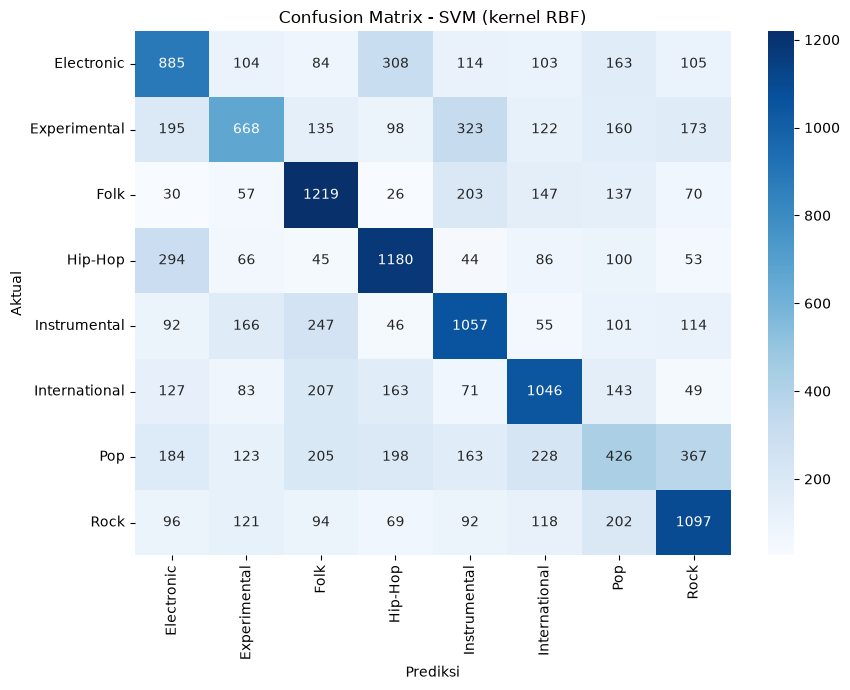

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm, labels=svm_model.classes_)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - SVM (kernel RBF)')
plt.tight_layout()
plt.show()

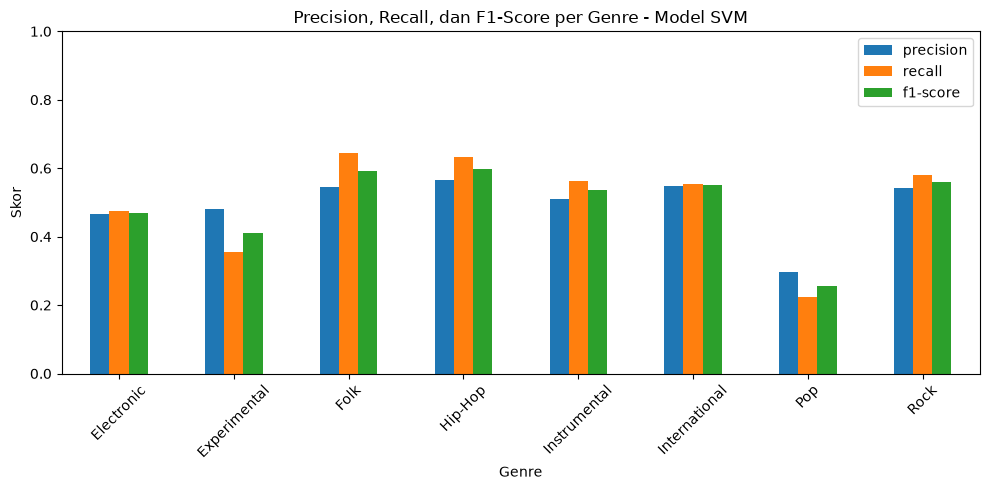

In [14]:
metrics_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'])[['precision', 'recall', 'f1-score']]

metrics_df.plot(kind='bar', figsize=(10, 5))
plt.title('Precision, Recall, dan F1-Score per Genre - Model SVM')
plt.ylabel('Skor')
plt.xlabel('Genre')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

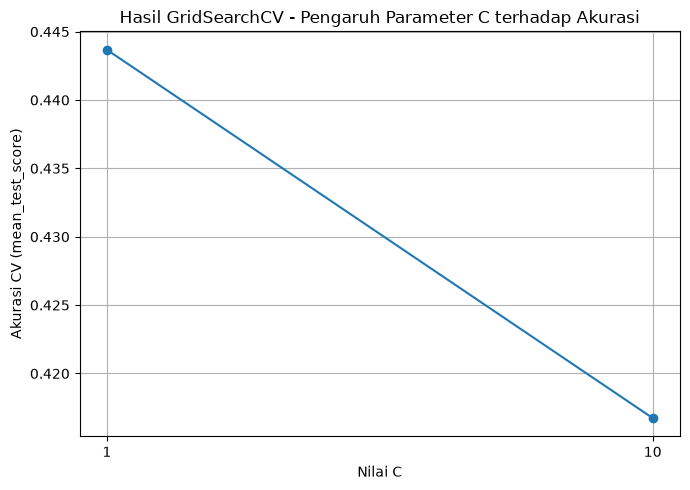

In [15]:
cv_results = pd.DataFrame(grid_svm.cv_results_)
cv_results_sorted = cv_results[['param_C', 'param_kernel', 'mean_test_score']].sort_values('param_C')

plt.figure(figsize=(7, 5))
plt.plot(cv_results_sorted['param_C'].astype(str), cv_results_sorted['mean_test_score'], marker='o')
plt.xlabel('Nilai C')
plt.ylabel('Akurasi CV (mean_test_score)')
plt.title('Hasil GridSearchCV - Pengaruh Parameter C terhadap Akurasi')
plt.grid(True)
plt.tight_layout()
plt.show()

### Perbandingan Model

In [ ]:
import joblib

joblib.dump(svm_model, 'data/best_model.pkl')
joblib.dump(scaler, 'data/scaler.pkl')

model_info = {'model_type': 'SVM', 'needs_scaling': True}
joblib.dump(model_info, 'data/model_info.pkl')

print("Model SVM, scaler, dan model_info berhasil disimpan.")